**In this notebook we establish that the tone onset delays cause a corresponding delay in the appearance of N100 peaks in the ERPs corresponding to standard tones.  
These delays therefore need to be accounted when computing the MMN latency.**

In [1]:
from os import path
from glob import glob

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

rawdir = '../data/raw/'
resultdir = '../data/results/'

triggers = dict(
    S14='BN STD',
    S15='SN DEV',
    S24='SN STD',
    S25='BN DEV',
    S34='CN STD',
    S35='BN DEV',
)

ch_order = ['TP10', 'CP5', 'C5', 'FC5', 'C6', 'T8', 'C3', 'TP8', 'C4', 'C1', 'P5',
       'FT8', 'CP3', 'F7', 'TP9', 'FC1', 'C2', 'F3', 'FC6', 'TP7', 'F2', 'Fz',
       'FC3', 'Cz', 'P7', 'F1', 'FC2', 'AF3', 'Fp1', 'AFz', 'FC4', 'FCz', 'P8',
       'Fp2', 'FT7', 'P1', 'F8', 'AF4', 'CP2', 'F4', 'P3', 'CPz', 'T7', 'CP1',
       'Pz', 'CP4', 'F5', 'P4', 'PO7', 'CP6', 'AF8', 'AF7', 'FT9', 'P2', 'PO8',
       'P6', 'PO4', 'PO3', 'FT10', 'POz', 'F6', 'O1', 'O2', 'Oz']

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
delays = participants['Tone_delay'].rename('tone delay')

In [3]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = glob(path.join(rawdir, 'preprocessed', '*'))
print(len(files))
sorted(files)

58


['../data/raw/preprocessed/sub-sd011-epo.fif',
 '../data/raw/preprocessed/sub-sd012-epo.fif',
 '../data/raw/preprocessed/sub-sd013-epo.fif',
 '../data/raw/preprocessed/sub-sd015-epo.fif',
 '../data/raw/preprocessed/sub-sd016-epo.fif',
 '../data/raw/preprocessed/sub-sd017-epo.fif',
 '../data/raw/preprocessed/sub-sd018-epo.fif',
 '../data/raw/preprocessed/sub-sd019-epo.fif',
 '../data/raw/preprocessed/sub-sd020-epo.fif',
 '../data/raw/preprocessed/sub-sd021-epo.fif',
 '../data/raw/preprocessed/sub-sd022-epo.fif',
 '../data/raw/preprocessed/sub-sd023-epo.fif',
 '../data/raw/preprocessed/sub-sd024-epo.fif',
 '../data/raw/preprocessed/sub-sd024_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd025-epo.fif',
 '../data/raw/preprocessed/sub-sd025_without_downsample-epo.fif',
 '../data/raw/preprocessed/sub-sd026-epo.fif',
 '../data/raw/preprocessed/sub-sd027-epo.fif',
 '../data/raw/preprocessed/sub-sd028-epo.fif',
 '../data/raw/preprocessed/sub-sd029-epo.fif',
 '../data/raw/preproce

# Manual check of delayed responses for delayed tones

In [12]:
# read epoched data for a 'normal' and a 'delayed' tone subject
data = {
    'sd53': mne.read_epochs('../data/raw/preprocessed/sub-sd053-epo.fif'),
    'sd40': mne.read_epochs('../data/raw/preprocessed/sub-sd040-epo.fif'),
    'sd48': mne.read_epochs('../data/raw/preprocessed/sub-sd048-epo.fif'),
    'sd32': mne.read_epochs('../data/raw/preprocessed/sub-sd032-epo.fif'),
    'sd35': mne.read_epochs('../data/raw/preprocessed/sub-sd035-epo.fif'),
    'sd19': mne.read_epochs('../data/raw/preprocessed/sub-sd019-epo.fif'),
    'sd45': mne.read_epochs('../data/raw/preprocessed/sub-sd045-epo.fif'),
}

Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd053-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
2320 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd040-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
2158 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jupyter-saurabh/Github/ecf-exp2-notif-mmn/analysis/../data/raw/preprocessed/sub-sd048-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
2379 matching events found
No baseline correction applied
0 projection

In [13]:
# compute average evoked response to different stimuli
# independent of the trial kind (STD or DEV) to get the stimulus-specific response
erps_ave, erps_sem = {}, {}
for cond, epochs in data.items():
    epochs = epochs.apply_baseline().to_data_frame()
    epochs[['stim', 'kind']] = epochs.condition.map(triggers).str.split(' ', expand=True)
    epochs = epochs.drop('condition', axis=1)
    erps_ave[cond] = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).mean()
    erps_sem[cond] = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).sem()
erps_ave = pd.concat(erps_ave, names=['tone'])
erps_sem = pd.concat(erps_sem, names=['tone'])
erps = pd.concat(dict(ave=erps_ave, sem=erps_sem))

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


In [14]:
erps_std = erps_ave.loc[:, :, -0.3:0.15].groupby(['tone', 'stim']).std()
erps_bsl = erps_ave.loc[:, :, -0.3:0.15].groupby(['tone', 'stim']).mean()

In [15]:
erps_ave

Fp1        Fz        F3        F7       FT9  \
tone stim time                                                          
sd53 BN   -0.300781 -0.688641 -1.337210 -1.037325 -0.657354  0.277054   
          -0.298828 -0.666422 -1.264593 -0.960217 -0.578716  0.252545   
          -0.296875 -0.650759 -1.184135 -0.882019 -0.490972  0.190500   
          -0.294922 -0.639875 -1.099079 -0.806626 -0.402760  0.095389   
          -0.292969 -0.631200 -1.013000 -0.737252 -0.321568 -0.024080   
...                       ...       ...       ...       ...       ...   
sd45 SN    0.892578 -0.442229  2.115205  1.956985  0.486335 -0.327909   
           0.894531 -0.358155  2.317628  2.103460  0.531256 -0.302903   
           0.896484 -0.277685  2.511420  2.231855  0.579663 -0.261676   
           0.898438 -0.199879  2.687788  2.337591  0.631749 -0.205757   
           0.900391 -0.122806  2.839219  2.417888  0.687512 -0.139139   

                          FC5       FC1        C3        T7       TP9  ...  \
tone stim time                                                         ...   
sd53 BN   -0.300781 -0.664728 -1.529426 -1.105662  0.524145  0.147043  ...   
          -0.298828 -0.634934 -1.443701 -1.018556  0.506080  0.103404  ...   
          -0.296875 -0.611096 -1.344262 -0.930142  0.469112  0.065015  ...   
          -0.294922 -0.594899 -1.236080 -0.845849  0.418510  0.033984  ...   
          -0.292969 -0.586195 -1.125072 -0.770446  0.361487  0.011505  ...   
...                       ...       ...       ...       ...       ...  ...   
sd45 SN    0.892578  1.709231  2.008819  1.594630  0.195393  0.139648  ...   
           0.894531  1.799732  2.229579  1.740979  0.270088  0.133054  ...   
           0.896484  1.881007  2.435941  1.872829  0.345686  0.123610  ...   
           0.898438  1.950258  2.615954  1.983908  0.421061  0.113289  ...   
           0.900391  2.006191  2.759730  2.070379  0.495988  0.104142  ...   

                           C6        C2       FC4       FT8        F6  \
tone stim time                                                          
sd53 BN   -0.300781 -0.867607 -1.100108 -1.286760 -0.752623 -0.852263   
          -0.298828 -0.799934 -1.013080 -1.230718 -0.703784 -0.849799   
          -0.296875 -0.738108 -0.923860 -1.162112 -0.649739 -0.846236   
          -0.294922 -0.683188 -0.836743 -1.084647 -0.593594 -0.837148   
          -0.292969 -0.635477 -0.755557 -1.003261 -0.537637 -0.818912   
...                       ...       ...       ...       ...       ...   
sd45 SN    0.892578  1.699694  1.758499  1.921002  1.314856  1.939148   
           0.894531  1.702150  1.914711  2.056659  1.356624  2.053286   
           0.896484  1.689701  2.058673  2.170115  1.383573  2.143277   
           0.898438  1.665411  2.183156  2.256488  1.397343  2.207247   
           0.900391  1.633296  2.282897  2.313652  1.399195  2.245720   

                          AF8       AF4        F2       FCz        Cz  
tone stim time                                                         
sd53 BN   -0.300781 -0.536453 -0.878716 -1.310279 -1.370234 -1.122462  
          -0.298828 -0.446268 -0.842698 -1.251041 -1.298414 -1.052710  
          -0.296875 -0.367707 -0.811300 -1.187279 -1.222676 -0.979196  
          -0.294922 -0.305430 -0.784612 -1.120324 -1.145366 -0.903445  
          -0.292969 -0.262470 -0.762151 -1.051663 -1.069016 -0.827153  
...                       ...       ...       ...       ...       ...  
sd45 SN    0.892578  0.993296  1.999506  2.001612  2.106724  1.899400  
           0.894531  1.140637  2.168602  2.187434  2.340730  2.109523  
           0.896484  1.251523  2.328939  2.364201  2.564723  2.311633  
           0.898438  1.320086  2.472822  2.523532  2.765640  2.494197  
           0.900391  1.344166  2.593899  2.658020  2.932768  2.647489  

[11704 rows x 64 columns]

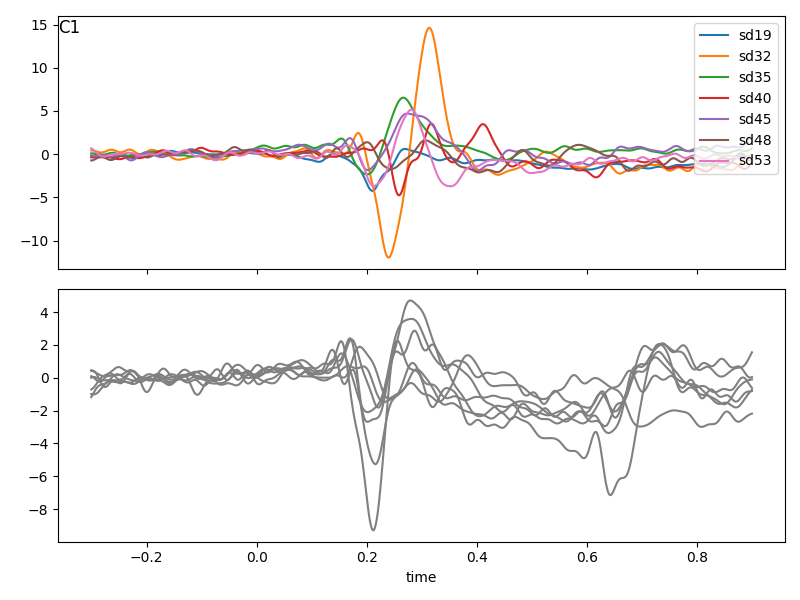

In [16]:
electrode = 'C1'

f, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6), tight_layout=True, sharex=True)

erps_ave.xs('BN', level='stim')[electrode].groupby(['tone']).apply(
    lambda s: s.droplevel([0]).plot(ax=ax2, label='_', c='gray')
)
erps_ave.xs('SN', level='stim')[electrode].groupby(['tone']).apply(
    lambda s: s.droplevel([0]).plot(ax=ax, label=s.name)#, yerr=erps_std.loc[s.name, 'SN'][electrode])
)

# plot style 1
ax.set_prop_cycle(plt.rcParams['axes.prop_cycle'])
# for stim in erps_std.index.levels[0]:
#     ax.fill_between(
#         erps_ave.groupby('time').mean().index,
#         erps_bsl.loc[(stim, 'SN')][electrode] - erps_std.loc[(stim, 'SN')][electrode]*2.5,
#         erps_bsl.loc[(stim, 'SN')][electrode] + erps_std.loc[(stim, 'SN')][electrode]*2.5,
#         alpha=0.1
#     )

# # plot style 2
# erps.xs('SN', level='stim')[electrode].groupby(['tone']).apply(
#     lambda s: s.loc['ave'].droplevel(0).plot(ax=ax, label=s.name, yerr=s.loc['sem'].droplevel(0))
# )
# for chd in ax.get_children():
#     if type(chd)==mpl.collections.LineCollection:
#         chd.set_alpha(0.1);

ax.set_title(electrode, loc='left', y=0.9)
ax.legend()

## N100 vs N100-P160 complex

In [18]:
erps_ave

Fp1        Fz        F3        F7       FT9  \
tone stim time                                                          
sd53 BN   -0.300781 -0.688641 -1.337210 -1.037325 -0.657354  0.277054   
          -0.298828 -0.666422 -1.264593 -0.960217 -0.578716  0.252545   
          -0.296875 -0.650759 -1.184135 -0.882019 -0.490972  0.190500   
          -0.294922 -0.639875 -1.099079 -0.806626 -0.402760  0.095389   
          -0.292969 -0.631200 -1.013000 -0.737252 -0.321568 -0.024080   
...                       ...       ...       ...       ...       ...   
sd45 SN    0.892578 -0.442229  2.115205  1.956985  0.486335 -0.327909   
           0.894531 -0.358155  2.317628  2.103460  0.531256 -0.302903   
           0.896484 -0.277685  2.511420  2.231855  0.579663 -0.261676   
           0.898438 -0.199879  2.687788  2.337591  0.631749 -0.205757   
           0.900391 -0.122806  2.839219  2.417888  0.687512 -0.139139   

                          FC5       FC1        C3        T7       TP9  ...  \
tone stim time                                                         ...   
sd53 BN   -0.300781 -0.664728 -1.529426 -1.105662  0.524145  0.147043  ...   
          -0.298828 -0.634934 -1.443701 -1.018556  0.506080  0.103404  ...   
          -0.296875 -0.611096 -1.344262 -0.930142  0.469112  0.065015  ...   
          -0.294922 -0.594899 -1.236080 -0.845849  0.418510  0.033984  ...   
          -0.292969 -0.586195 -1.125072 -0.770446  0.361487  0.011505  ...   
...                       ...       ...       ...       ...       ...  ...   
sd45 SN    0.892578  1.709231  2.008819  1.594630  0.195393  0.139648  ...   
           0.894531  1.799732  2.229579  1.740979  0.270088  0.133054  ...   
           0.896484  1.881007  2.435941  1.872829  0.345686  0.123610  ...   
           0.898438  1.950258  2.615954  1.983908  0.421061  0.113289  ...   
           0.900391  2.006191  2.759730  2.070379  0.495988  0.104142  ...   

                           C6        C2       FC4       FT8        F6  \
tone stim time                                                          
sd53 BN   -0.300781 -0.867607 -1.100108 -1.286760 -0.752623 -0.852263   
          -0.298828 -0.799934 -1.013080 -1.230718 -0.703784 -0.849799   
          -0.296875 -0.738108 -0.923860 -1.162112 -0.649739 -0.846236   
          -0.294922 -0.683188 -0.836743 -1.084647 -0.593594 -0.837148   
          -0.292969 -0.635477 -0.755557 -1.003261 -0.537637 -0.818912   
...                       ...       ...       ...       ...       ...   
sd45 SN    0.892578  1.699694  1.758499  1.921002  1.314856  1.939148   
           0.894531  1.702150  1.914711  2.056659  1.356624  2.053286   
           0.896484  1.689701  2.058673  2.170115  1.383573  2.143277   
           0.898438  1.665411  2.183156  2.256488  1.397343  2.207247   
           0.900391  1.633296  2.282897  2.313652  1.399195  2.245720   

                          AF8       AF4        F2       FCz        Cz  
tone stim time                                                         
sd53 BN   -0.300781 -0.536453 -0.878716 -1.310279 -1.370234 -1.122462  
          -0.298828 -0.446268 -0.842698 -1.251041 -1.298414 -1.052710  
          -0.296875 -0.367707 -0.811300 -1.187279 -1.222676 -0.979196  
          -0.294922 -0.305430 -0.784612 -1.120324 -1.145366 -0.903445  
          -0.292969 -0.262470 -0.762151 -1.051663 -1.069016 -0.827153  
...                       ...       ...       ...       ...       ...  
sd45 SN    0.892578  0.993296  1.999506  2.001612  2.106724  1.899400  
           0.894531  1.140637  2.168602  2.187434  2.340730  2.109523  
           0.896484  1.251523  2.328939  2.364201  2.564723  2.311633  
           0.898438  1.320086  2.472822  2.523532  2.765640  2.494197  
           0.900391  1.344166  2.593899  2.658020  2.932768  2.647489  

[11704 rows x 64 columns]

# Relationship between first ERP peak (N100) and tone onset delay

In [4]:
def find_peak(erp, approx_latency=0.2, time_range=0.1):
    try:
        _times = erp.index
        _peaks, _mags = mne.preprocessing.peak_finder(erp, extrema=-1, verbose='ERROR')
        peak_times = pd.Series(_times[_peaks], index=_peaks)
        _mags = pd.Series(_mags, index=_peaks)
        # find the peaks near to the approximate latency
        nearest_peaks = peak_times[
            (peak_times<approx_latency+time_range)&(peak_times>approx_latency-time_range)
        ]
        # return the time of the largest peak in the vicinity
        return _times[_mags[nearest_peaks.index].idxmin()]
    except Exception as e:
        # print(_peaks, peak_times, nearest_peaks)
        # print(erp.name, e)
        return None

def get_n100_latencies(fname):
    epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR').to_data_frame()
    epochs[['stim', 'kind']] = epochs.condition.map(triggers).str.split(' ', expand=True)
    epochs = epochs.drop('condition', axis=1)
    # compute the erp for each channel
    ave = epochs.drop(['epoch', 'kind'], axis=1).groupby(['stim', 'time']).mean()
    # also compute the mean across relevant channels
    ave['mean'] = ave[ch_order[:40]].mean(axis=1)
    # get the peak closest to expected latency
    sn_peaks = ave.loc['SN'].stack().groupby(level=1).apply(
        lambda s: find_peak(s.droplevel(1), approx_latency=delays[path.basename(fname).split('-')[1]]+0.2)
    ).rename('SN')
    bn_peaks = ave.loc['BN'].stack().groupby(level=1).apply(
        lambda s: find_peak(s.droplevel(1), approx_latency=0.2)
    ).rename('BN')
    return pd.concat([sn_peaks, bn_peaks], axis=1)

In [5]:
peaks = {}
for file in tqdm(files):
    if 'without' not in file:
        sub = path.basename(file).split('-')[1]
        peaks[sub] = get_n100_latencies(file).T
peaks = pd.concat(peaks).swaplevel().sort_index()
peaks.to_csv(path.join(resultdir, 'n100_latencies.csv'))
peaks

  0%|          | 0/58 [00:00<?, ?it/s]

AF3       AF4       AF7       AF8       AFz        C1  \
BN sd011  0.201172  0.199219  0.199219  0.199219  0.199219  0.201172   
   sd012  0.240234  0.240234  0.240234  0.236328  0.240234  0.238281   
   sd013  0.232422  0.242188  0.234375  0.189453  0.238281  0.236328   
   sd015  0.234375  0.232422  0.191406       NaN  0.246094  0.248047   
   sd016  0.234375  0.234375  0.226562  0.232422  0.232422  0.232422   
...            ...       ...       ...       ...       ...       ...   
SN sd063  0.205078  0.207031  0.205078  0.205078  0.205078  0.207031   
   sd064  0.236328  0.240234  0.242188  0.244141  0.236328  0.123047   
   sd065  0.216797  0.214844  0.212891  0.244141  0.214844  0.212891   
   sd066  0.230469  0.228516  0.230469  0.230469  0.228516  0.230469   
   sd067  0.242188  0.246094  0.242188  0.242188  0.246094  0.248047   

                C2        C3        C4        C5  ...       PO8       POz  \
BN sd011  0.195312  0.201172  0.195312  0.197266  ...  0.199219  0.201172   
   sd012  0.244141  0.236328  0.240234  0.238281  ...  0.244141  0.240234   
   sd013  0.238281  0.238281  0.246094  0.240234  ...  0.271484  0.160156   
   sd015  0.189453  0.251953  0.248047  0.251953  ...  0.257812  0.257812   
   sd016  0.232422  0.234375  0.216797  0.242188  ...  0.162109  0.208984   
...            ...       ...       ...       ...  ...       ...       ...   
SN sd063  0.205078  0.207031  0.205078  0.205078  ...  0.175781  0.181641   
   sd064  0.212891  0.236328  0.242188  0.226562  ...  0.205078  0.207031   
   sd065  0.212891  0.242188  0.210938  0.244141  ...  0.212891  0.208984   
   sd066  0.232422  0.230469  0.228516  0.234375  ...  0.167969  0.236328   
   sd067  0.246094  0.244141  0.246094  0.234375  ...  0.216797  0.214844   

                Pz        T7        T8      TP10       TP7       TP8  \
BN sd011  0.197266  0.199219  0.265625  0.244141  0.205078  0.195312   
   sd012  0.242188  0.234375  0.238281  0.263672  0.236328  0.246094   
   sd013  0.238281  0.191406  0.281250  0.263672  0.191406  0.267578   
   sd015  0.263672  0.205078  0.185547  0.117188  0.193359  0.253906   
   sd016  0.208984  0.226562  0.259766  0.296875  0.214844  0.275391   
...            ...       ...       ...       ...       ...       ...   
SN sd063  0.207031  0.242188  0.238281  0.230469  0.201172  0.242188   
   sd064  0.210938  0.242188  0.193359  0.187500  0.224609  0.201172   
   sd065  0.244141  0.248047  0.232422  0.291016  0.248047  0.251953   
   sd066  0.228516  0.251953  0.236328  0.277344  0.232422  0.234375   
   sd067  0.250000  0.238281  0.236328  0.226562  0.298828  0.230469   

               TP9      mean  
BN sd011  0.214844  0.199219  
   sd012  0.195312  0.238281  
   sd013  0.195312  0.238281  
   sd015  0.214844  0.251953  
   sd016  0.220703  0.232422  
...            ...       ...  
SN sd063  0.195312  0.205078  
   sd064  0.222656  0.240234  
   sd065  0.140625  0.242188  
   sd066  0.117188  0.230469  
   sd067  0.255859  0.244141  

[108 rows x 65 columns]

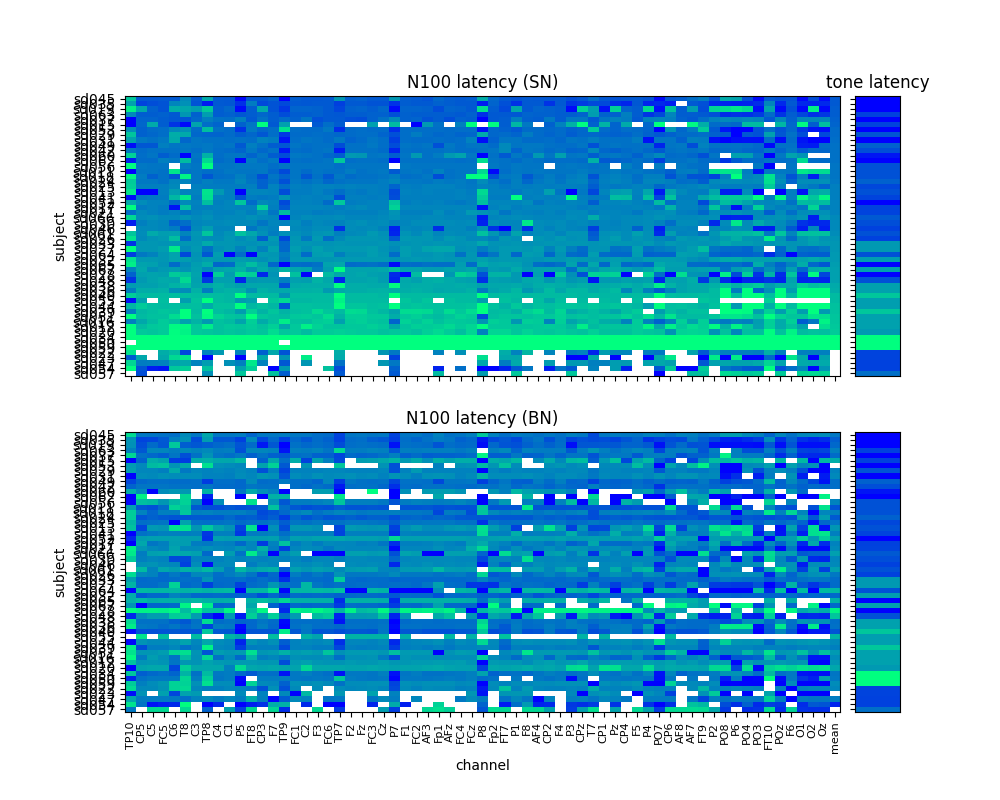

In [6]:
subject_order = peaks.loc['SN']['mean'].sort_values().index

f, ((ax, axd), (ax2, axd2)) = plt.subplots(
    2, 2, figsize=(10, 8), width_ratios=[8, 0.5],
    sharey=True, gridspec_kw=dict(wspace=0.04)
)

ax.sharex(ax2)

# show the actual latencies
ax.imshow(
    peaks.loc['SN'][ch_order+['mean']].loc[subject_order],
    aspect='auto', cmap='winter', vmin=0.15, vmax=0.3
)

# show the tone latency
axd.imshow(
    np.log(pd.DataFrame(delays).loc[subject_order]), aspect='auto',
    vmin=np.log(0.002), vmax=np.log(0.2), cmap='winter'
)

# show the actual latencies
ax2.imshow(
    peaks.loc['BN'][ch_order+['mean']].loc[subject_order],
    aspect='auto', cmap='winter', vmin=0.15, vmax=0.3
)

# show the tone latency
axd2.imshow(
    np.log(pd.DataFrame(delays).loc[subject_order]), aspect='auto',
    vmin=np.log(0.002), vmax=np.log(0.2), cmap='winter'
)

ax2.set_xlabel('channel')
ax2.set_ylabel('subject')
ax.set_ylabel('subject')
ax2.set_xticks(range(65))
ax2.set_xticklabels(ch_order+['mean'], rotation=90, fontsize=8)
ax.set_yticks(range(peaks.shape[0]//2))
ax.set_yticklabels(subject_order)
ax2.set_yticks(range(peaks.shape[0]//2))
ax2.set_yticklabels(subject_order)
axd.set_xticks([])
axd2.set_xticks([])
ax.set_title('N100 latency (SN)')
ax2.set_title('N100 latency (BN)')
axd.set_title('tone latency')
plt.setp(ax.get_xticklabels(), visible=False);

## average N100 latency across channels

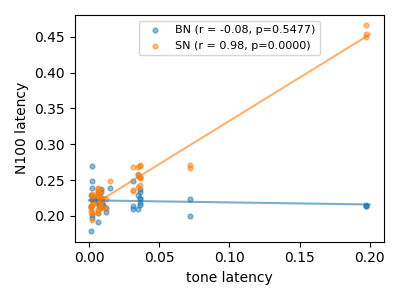

In [7]:
f, ax = plt.subplots(figsize=(4, 3), tight_layout=True)

# compute correlation and significance
rp = dict(m={}, c={}, r={}, p={}, se={})
for k in ['BN', 'SN']:
    idx = peaks.loc[k][ch_order].mean(axis=1).dropna().index
    rp['m'][k], rp['c'][k], rp['r'][k], rp['p'][k], rp['se'][k] = linregress(
        delays.loc[peaks.loc[k].index][idx], peaks.loc[k][ch_order].mean(axis=1)[idx]
    )

for k in ['BN', 'SN']:
    ax.scatter(
        delays.loc[peaks.loc[k].index], peaks.loc[k].mean(axis=1),
        s=12, alpha=0.5, label=f'{k} (r = {rp["r"][k]:.2f}, p={rp["p"][k]:.4f})'
    )
    ax.plot([0, 0.2], rp["m"][k]*np.array([0, 0.2])+rp["c"][k], alpha=0.6)
ax.set_xlabel('tone latency')
ax.set_ylabel('N100 latency')
ax.legend(fontsize=8, loc=9);

## N100 latency of ERP averaged across channels

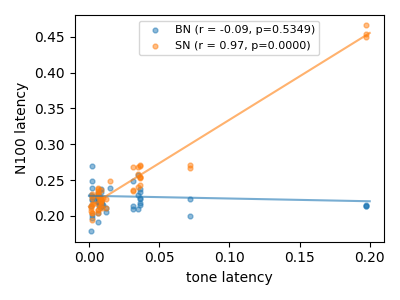

In [8]:
f, ax = plt.subplots(figsize=(4, 3), tight_layout=True)

# compute correlation and significance
rp = dict(m={}, c={}, r={}, p={}, se={})
for k in ['BN', 'SN']:
    idx = peaks['mean'][k].dropna().index
    rp['m'][k], rp['c'][k], rp['r'][k], rp['p'][k], rp['se'][k] = linregress(
        delays.loc[peaks.loc[k].index][idx], peaks['mean'][k][idx]
    )

for k in ['BN', 'SN']:
    ax.scatter(
        delays.loc[peaks.loc[k].index], peaks.loc[k].mean(axis=1),
        s=12, alpha=0.5, label=f'{k} (r = {rp["r"][k]:.2f}, p={rp["p"][k]:.4f})'
    )
    ax.plot([0, 0.2], rp["m"][k]*np.array([0, 0.2])+rp["c"][k], alpha=0.6)
ax.set_xlabel('tone latency')
ax.set_ylabel('N100 latency')
ax.legend(fontsize=8, loc=9);

# N100 latency distribution and variation

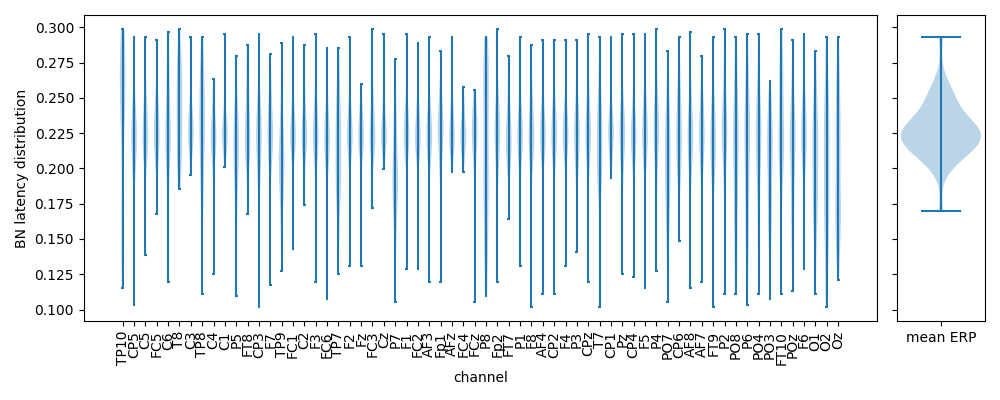

In [9]:
f, (ax, ax2) = plt.subplots(
    1, 2, figsize=(10, 4), width_ratios=[0.9, 0.1],
    tight_layout=True, sharey=True
)
ax.violinplot([peaks.loc['BN'][c].dropna() for c in ch_order])
ax.set_xticks(np.arange(64)+1)
ax.set_xticklabels(ch_order, rotation=90)
ax.set_xlabel('channel')
ax.set_ylabel('BN latency distribution')
ax2.violinplot(peaks.loc['BN']['mean'].dropna())
ax2.set_xticks([1])
ax2.set_xticklabels(['mean ERP']);